# 06 — Stats inter-conditions

Test de l'effet de la condition (silence / tempo_random / beatmove_adaptatif) sur les 5 métriques de résilience.

## Méthode

**Design** : measures répétées intra-sujet (3 conditions par participant)

**Test omnibus** : **Friedman** (non-paramétrique, alternative aux ANOVA répétées)
- H0 : les distributions des 3 conditions sont identiques
- Effect size : **Kendall's W** (= χ² / [N(k-1)], ≤0.1 small, ~0.3 medium, ≥0.5 large)

**Post-hoc** (si Friedman significatif) : **Wilcoxon apparié** sur les 3 paires (sil-tem, sil-bea, tem-bea)
- Correction **Bonferroni** : α = 0.05 / 3 = **0.0167**
- Effect size : **r = Z / √N** (Rosenthal 1991, ~0.1 small, ~0.3 medium, ~0.5 large)

**Filtrage** : seuls les participants avec les 3 conditions valides (no NaN) sont gardés (paires complètes requises).

## Hypothèse principale

**beatmove_adaptatif < tempo_random** sur les métriques de "coût de la perturbation" (z_var, z_radius, ratios) → l'auditory cueing adaptatif atténue l'impact de la perturbation par rapport à un cueing aléatoire.

## Inputs

- `outputs/tables/05_resilience_metrics.csv`

In [2]:
from resilience import paths
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, wilcoxon
from pathlib import Path
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

## Chargement

In [3]:
RES_CSV = Path(paths.OUTPUTS_DIR) / 'tables' / '05_resilience_metrics.csv'
df = pd.read_csv(RES_CSV)
print(f"✅ {len(df)} essais chargés ({df['participant'].nunique()} participants)")

METRICS = ['z_var', 'z_radius', 'ratio_var', 'ratio_radius', 'delta_cadence_hz']
COND_ORDER = ['silence', 'tempo_random', 'beatmove_adaptatif']
COND_COLORS = {'silence': 'steelblue', 'tempo_random': 'darkorange', 'beatmove_adaptatif': 'forestgreen'}

df.head()

✅ 35 essais chargés (13 participants)


,participant,condition,n_baseline_passages,pert_duration_s,pert_var,pert_radius,pert_cadence,baseline_var,baseline_radius,baseline_cadence,z_var,z_radius,ratio_var,ratio_radius,delta_cadence_hz
0,001CrMa,silence,32,4.8600,168.7300,26.6700,1.6170,121.8100,22.5600,1.8430,3.0000,2.6300,1.3900,1.1800,-0.2260
1,001CrMa,tempo_random,41,4.3500,247.6100,32.6100,1.6800,147.5100,24.5300,1.8950,1.4000,2.0700,1.6800,1.3300,-0.2140
2,001CrMa,beatmove_adaptatif,18,4.1800,455.9800,52.1600,1.7180,171.5900,26.1600,1.8640,10.5800,11.8100,2.6600,1.9900,-0.1460
3,002CrPa,silence,20,4.9600,118.7800,22.3400,1.0000,83.9200,18.3700,1.8750,4.2800,4.4600,1.4200,1.2200,-0.8750
4,002CrPa,beatmove_adaptatif,18,4.9300,112.1500,22.0100,1.2150,72.2500,16.9900,1.6750,5.7300,5.4600,1.5500,1.3000,-0.4600


In [4]:
# Filtre PAR MÉTRIQUE : pour chaque métrique, on garde les participants
# qui ont les 3 conditions valides POUR CETTE METRIQUE.
# Justification : `delta_cadence_hz` pénalise inutilement les autres tests
# en filtrant globalement (perd P003 et P013 pour 1 NaN sur delta).
pivots = {m: df.pivot(index='participant', columns='condition', values=m).reindex(columns=COND_ORDER)
          for m in METRICS}

pivots_clean = {m: pv.dropna() for m, pv in pivots.items()}

print(f"✅ N par métrique après filtrage (3 conditions valides) :")
for m, pv in pivots_clean.items():
    print(f"   {m:25s} : N = {len(pv):2d} participants  | {list(pv.index)}")

✅ N par métrique après filtrage (3 conditions valides) :
   z_var                     : N = 10 participants  | ['001CrMa', '002CrPa', '003BrLu', '004CaGe', '009DeFr', '010DeYv', '011RiJo', '012WaCh', '013WaJe', '014DeAn']
   z_radius                  : N = 10 participants  | ['001CrMa', '002CrPa', '003BrLu', '004CaGe', '009DeFr', '010DeYv', '011RiJo', '012WaCh', '013WaJe', '014DeAn']
   ratio_var                 : N = 10 participants  | ['001CrMa', '002CrPa', '003BrLu', '004CaGe', '009DeFr', '010DeYv', '011RiJo', '012WaCh', '013WaJe', '014DeAn']
   ratio_radius              : N = 10 participants  | ['001CrMa', '002CrPa', '003BrLu', '004CaGe', '009DeFr', '010DeYv', '011RiJo', '012WaCh', '013WaJe', '014DeAn']
   delta_cadence_hz          : N =  8 participants  | ['001CrMa', '002CrPa', '004CaGe', '009DeFr', '010DeYv', '011RiJo', '012WaCh', '014DeAn']


## Test Friedman + Wilcoxon par métrique

In [5]:
def wilcoxon_r(stat_w, n):
    """Effect size r = Z / sqrt(N) où Z = stat_w — approximation classique.
    scipy.stats.wilcoxon retourne W (sum of ranks), pas Z. On approxime Z
    via la normalisation classique pour grand n : Z = (W - mu) / sigma.
    """
    mu = n * (n + 1) / 4
    sigma = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    z = (stat_w - mu) / sigma
    return abs(z) / np.sqrt(n)


results_friedman = []
results_wilcoxon = []
PAIRS = [('silence', 'tempo_random'),
          ('silence', 'beatmove_adaptatif'),
          ('tempo_random', 'beatmove_adaptatif')]
BONF_ALPHA = 0.05 / len(PAIRS)

for metric in METRICS:
    pv = pivots_clean[metric]
    n = len(pv)
    k = 3

    # --- Friedman ---
    stat, p_fried = friedmanchisquare(*[pv[c].values for c in COND_ORDER])
    kendall_w = stat / (n * (k - 1))
    sig_fried = '***' if p_fried < 0.001 else '**' if p_fried < 0.01 else '*' if p_fried < 0.05 else 'ns'

    results_friedman.append({
        'metric':     metric,
        'N':          n,
        'chi2':       round(stat, 3),
        'df':         k - 1,
        'p':          round(p_fried, 4),
        'kendall_W':  round(kendall_w, 3),
        'sig':        sig_fried,
    })

    # --- Wilcoxon post-hoc (toujours, même si Friedman ns, pour info) ---
    for c1, c2 in PAIRS:
        diff = pv[c1].values - pv[c2].values
        # zero_method='wilcox' écarte les paires égales
        try:
            stat_w, p_w = wilcoxon(diff, zero_method='wilcox', alternative='two-sided')
        except ValueError:
            stat_w, p_w = np.nan, np.nan
        n_eff = int((diff != 0).sum())
        r = wilcoxon_r(stat_w, n_eff) if not np.isnan(stat_w) else np.nan
        sig_w = '***' if p_w < 0.001 else '**' if p_w < 0.01 else '*' if p_w < BONF_ALPHA else 'ns'
        results_wilcoxon.append({
            'metric':         metric,
            'pair':           f"{c1[:3]} vs {c2[:3]}",
            'N_eff':          n_eff,
            'W':              round(stat_w, 1) if not np.isnan(stat_w) else np.nan,
            'p_uncorrected':  round(p_w, 4) if not np.isnan(p_w) else np.nan,
            'p_bonf':         round(min(p_w * len(PAIRS), 1.0), 4) if not np.isnan(p_w) else np.nan,
            'r':              round(r, 3) if not np.isnan(r) else np.nan,
            'sig_bonf':       sig_w,
        })

df_friedman = pd.DataFrame(results_friedman)
df_wilcoxon = pd.DataFrame(results_wilcoxon)

print("="*70)
print("FRIEDMAN (omnibus)")
print("="*70)
print(df_friedman.to_string(index=False))

print("\n" + "="*70)
print(f"WILCOXON apparié post-hoc (Bonferroni α = {BONF_ALPHA:.4f})")
print("="*70)
print(df_wilcoxon.to_string(index=False))

FRIEDMAN (omnibus)
          metric  N   chi2  df      p  kendall_W sig
           z_var 10 1.4000   2 0.4966     0.0700  ns
        z_radius 10 0.6000   2 0.7408     0.0300  ns
       ratio_var 10 5.5900   2 0.0611     0.2790  ns
    ratio_radius 10 4.7890   2 0.0912     0.2390  ns
delta_cadence_hz  8 0.6090   2 0.7376     0.0380  ns

WILCOXON apparié post-hoc (Bonferroni α = 0.0167)
          metric       pair  N_eff       W  p_uncorrected  p_bonf      r sig_bonf
           z_var sil vs tem     10 15.0000         0.2324  0.6973 0.4030       ns
           z_var sil vs bea     10 23.0000         0.6953  1.0000 0.1450       ns
           z_var tem vs bea     10 14.0000         0.1934  0.5801 0.4350       ns
        z_radius sil vs tem     10 21.5000         0.5723  1.0000 0.1930       ns
        z_radius sil vs bea     10 26.0000         0.9219  1.0000 0.0480       ns
        z_radius tem vs bea     10 25.0000         0.8457  1.0000 0.0810       ns
       ratio_var sil vs tem     10  1.

## Statistiques descriptives par condition

In [6]:
df_desc = pd.DataFrame()
for metric in METRICS:
    pv = pivots_clean[metric]
    for cond in COND_ORDER:
        vals = pv[cond].values
        df_desc = pd.concat([df_desc, pd.DataFrame([{
            'metric':    metric,
            'condition': cond,
            'N':         len(vals),
            'median':    round(np.median(vals), 3),
            'iqr':       round(np.percentile(vals, 75) - np.percentile(vals, 25), 3),
            'mean':      round(np.mean(vals), 3),
            'sd':        round(np.std(vals, ddof=1), 3),
        }])], ignore_index=True)
df_desc

,metric,condition,N,median,iqr,mean,sd
0,z_var,silence,10,3.8200,4.8770,5.3960,3.9440
1,z_var,tempo_random,10,8.0100,6.2820,7.8750,4.5050
2,z_var,beatmove_adaptatif,10,5.2550,2.6700,5.9000,3.0490
3,z_radius,silence,10,3.6900,4.6100,4.7670,3.0780
4,z_radius,tempo_random,10,5.2750,3.3580,5.3530,2.5910
5,z_radius,beatmove_adaptatif,10,4.6750,2.0980,5.2590,3.0290
6,ratio_var,silence,10,1.4550,0.3900,1.6360,0.4120
7,ratio_var,tempo_random,10,1.8800,0.4650,1.9690,0.3990
8,ratio_var,beatmove_adaptatif,10,1.5350,0.4900,1.7200,0.4340
9,ratio_radius,silence,10,1.2400,0.1630,1.2990,0.1640


## Plot final : boxplots avec annotations p-values

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_21540\2068994195.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cond, labels=[c[:3] for c in COND_ORDER],
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_21540\2068994195.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cond, labels=[c[:3] for c in COND_ORDER],
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_21540\2068994195.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cond, labels=[c[:3] for c in COND_ORDER],
C:\Users\etulyon1\AppData\Local\Temp\ipykernel_21540\2068994195.py:16: Matpl

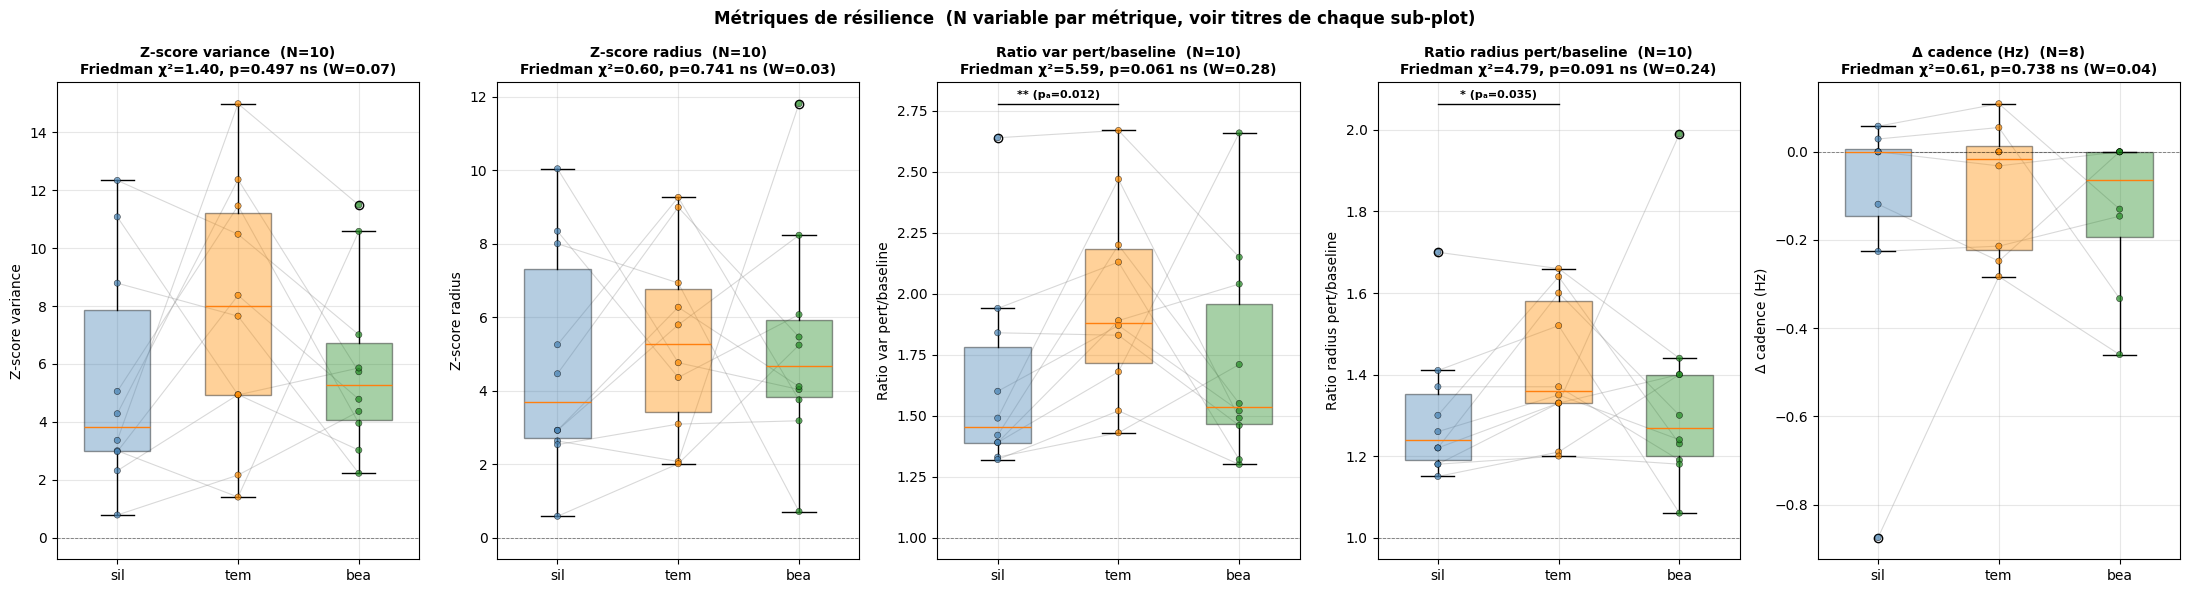

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(22, 6))

metrics_labels = {
    'z_var':            'Z-score variance',
    'z_radius':         'Z-score radius',
    'ratio_var':        'Ratio var pert/baseline',
    'ratio_radius':     'Ratio radius pert/baseline',
    'delta_cadence_hz': 'Δ cadence (Hz)',
}
ref_lines = {'z_var': 0, 'z_radius': 0, 'ratio_var': 1, 'ratio_radius': 1, 'delta_cadence_hz': 0}

for ax, metric in zip(axes, METRICS):
    pv = pivots_clean[metric]
    data_by_cond = [pv[c].values for c in COND_ORDER]

    bp = ax.boxplot(data_by_cond, labels=[c[:3] for c in COND_ORDER],
                     patch_artist=True, widths=0.55)
    for patch, c in zip(bp['boxes'], COND_ORDER):
        patch.set_facecolor(COND_COLORS[c])
        patch.set_alpha(0.4)

    # Lignes individuelles
    for p_code in pv.index:
        vals = pv.loc[p_code].values
        ax.plot([1, 2, 3], vals, '-', color='gray', alpha=0.3, linewidth=0.8, zorder=1)
        ax.scatter([1, 2, 3], vals, s=20, alpha=0.7,
                    c=[COND_COLORS[c] for c in COND_ORDER],
                    edgecolors='black', linewidths=0.4, zorder=2)

    ax.axhline(ref_lines[metric], color='black', linestyle='--', linewidth=0.6, alpha=0.5)

    # Annotations p-values
    fried_row = df_friedman[df_friedman['metric'] == metric].iloc[0]
    title = f"{metrics_labels[metric]}  (N={int(fried_row['N'])})\nFriedman χ²={fried_row['chi2']:.2f}, p={fried_row['p']:.3f} {fried_row['sig']} (W={fried_row['kendall_W']:.2f})"
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel(metrics_labels[metric], fontsize=10)
    ax.grid(alpha=0.3)

    # Annotations Wilcoxon (barres entre conditions si sig après Bonf)
    sub = df_wilcoxon[df_wilcoxon['metric'] == metric]
    pair_x = {'sil vs tem': (1, 2), 'sil vs bea': (1, 3), 'tem vs bea': (2, 3)}
    y_top = max(np.concatenate(data_by_cond))
    y_range = y_top - min(np.concatenate(data_by_cond))
    y_offset = y_range * 0.08

    for i, (_, row) in enumerate(sub.iterrows()):
        if row['sig_bonf'] != 'ns':
            x1, x2 = pair_x[row['pair']]
            y = y_top + y_offset * (i + 1)
            ax.plot([x1, x2], [y, y], 'k-', linewidth=1)
            ax.text((x1 + x2)/2, y + y_offset*0.2,
                     f"{row['sig_bonf']} (pₐ={row['p_bonf']:.3f})",
                     ha='center', fontsize=8, fontweight='bold')

plt.suptitle(f'Métriques de résilience  (N variable par métrique, voir titres de chaque sub-plot)',
              fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('06_stats_final.png', dpi=80, bbox_inches='tight')
plt.show()

## Export

In [8]:
out_dir = Path(paths.OUTPUTS_DIR) / 'tables'
out_dir.mkdir(parents=True, exist_ok=True)

df_friedman.to_csv(out_dir / '06_friedman.csv', index=False)
df_wilcoxon.to_csv(out_dir / '06_wilcoxon_posthoc.csv', index=False)
df_desc.to_csv(out_dir / '06_descriptive_stats.csv', index=False)

print(f"✅ Export :")
print(f"   {out_dir / '06_friedman.csv'}")
print(f"   {out_dir / '06_wilcoxon_posthoc.csv'}")
print(f"   {out_dir / '06_descriptive_stats.csv'}")

✅ Export :
   C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\tables\06_friedman.csv
   C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\tables\06_wilcoxon_posthoc.csv
   C:\Users\etulyon1\Desktop\MASTER_IEAP\INTERNSHIP\Stage_M1_2026\outputs\tables\06_descriptive_stats.csv


## Synthèse

À commenter après exécution :

| Métrique | Friedman p | sig | Kendall W | Paire significative | Direction |
|---|---|---|---|---|---|
| z_var | ... | ... | ... | ... | ... |
| z_radius | ... | ... | ... | ... | ... |
| ratio_var | ... | ... | ... | ... | ... |
| ratio_radius | ... | ... | ... | ... | ... |
| Δ cadence (Hz) | ... | ... | ... | ... | ... |

**Interprétation hypothèse principale (beatmove < tempo_random)** :
- Si `ratio_var` ou `z_var` montre tem > bea après Bonferroni → RAS adaptatif atténue effectivement la perturbation
- Si pas de différence après correction → effet présent en tendance mais sous-alimenté à N=14 ; à confirmer avec collecte complète (17 participants prévus)

Prochaine étape → **Notebook 07 : Plots mémoire** (figures finales prop).